# Introduction

In the previous notebooks, we introduced multivariate Gaussians and used Gaussian conditioning for Bayesian regression and Gaussian process regression. So far, the data was treated as a fixed collection of observations. In this notebook, we will consider a different setting where the quantity of interest evolves over time and new observations arrive sequentially.

Suppose that at time $t$ we have some hidden state $x_t$ which cannot be observed directly. Instead, we receive a noisy observation $y_t$ containing information about it. Our goal is to recursively update our knowledge about the hidden state as new observations arrive, that is, to infer
$$p(x_t \mid y_{1:t})$$

For linear dynamics, linear observations, and Gaussian noise, this posterior remains Gaussian and can be computed exactly using the Kalman filter. Conceptually, the algorithm repeatedly applies the Gaussian operations introduced earlier: first propagating a Gaussian through the state dynamics and then conditioning it on a new observation.

In this notebook, we will introduce linear Gaussian state-space models, derive and implement the Kalman filter, and extend it to Kalman smoothing, where future observations are also used to estimate past states. We will study the effects of process and observation noise and model misspecification, consider the discretization of continuous-time state-space models, and finally introduce the Extended Kalman Filter for nonlinear dynamics and observation models.

# Imports and Setup

In [1]:
import sys
import warnings
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent

warnings.filterwarnings('ignore')
sys.path.append(str(PROJECT_ROOT))

In [2]:
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
from jax import random
from matplotlib import patches
from matplotlib.axes import Axes

KEY = random.key(47)

# Linear Gaussian State-Space Model

In this section we will define the model and connect the idea to the ideas we have discussed before.

## Latent State & Dynamics

Suppose we want to measure some value that is changing over time. Let us have a moving car and a GPS tracker that we want to use as a position measuring tool. We can just measure the position of the car over time directly, but since car is moving, we can suppose the car position dynamics. Let the car's state be described as
$$ x_t = \begin{bmatrix} p_t \\ v_t \end{bmatrix} $$
where $p_t$ is the position and $v_t$ is the velocity of the car at time $t$.
For a constant-speed car we can assume:
$$ p_t = p_{t-1} + v_{t-1} \Delta t, \quad v_t = v_{t-1} $$
Generally, we can describe the dynamics as
$$ x_t = A x_{t-1} + q_t, \quad q_t \sim \mathcal{N}(0, Q) $$
$$ A = \begin{bmatrix} 1 & \Delta t \\ 0 & 1 \end{bmatrix} $$
where $q_t$ is the **process noise**.

Given the above dynamics,
$$ x_t \mid x_{t-1} \sim \mathcal{N} (Ax_{t-1}, Q) $$
Basically, we are claiming that given the previous state, we expect the next state to be around $Ax_{t-1}$, but we are uncertain about it.

As in the previously discussed topics, $Q$ regulates the uncertainty:
* large $Q$ imposes high uncertainty about the state dynamics
* small $Q$ imposes low uncertainty about the state dynamics

## Observation Model

Now we need to describe how our observations relate to the latent space. Suppose we have observed the car's position using our GPS tracker, then our noisy observation $y_t$ is equal to the car's true position $p_t$ plus some observation noise. Let us model it using:
$$ y_t = p_t + \text{noise} $$
or, in general
$$ y_t = Hx_t + r_t, \quad r_t \sim \mathcal{N}(0, R) $$
in our case $H = \begin{bmatrix} 1 & 0 \end{bmatrix}$

As before, $R$ describes how uncertain are we about our measurements.

So, we have a model with recurring measurements of the form:
$$ 
\begin{aligned}
x_{t-1} & \to & x_{t} & \to & x_{t+1} & \to & \dots \\
\downarrow & & \downarrow & & \downarrow & & & \\
y_{t-1} & & y_t & & y_{t+1} & &
\end{aligned}
$$
with two different noise:
* **process noise** $q_t \sim \mathcal{N}(0, Q)$ telling us how uncertain are we about the **world**
* **measurement noise** $r_t \sim \mathcal{N}(0, R)$ telling us how uncertain are we about the **observations**

## Bayesian Inference

At time $t$ we want to quantify the latent state $x_t$ given the measurements we already have $y_1, y_2, \dots, y_t$, namely
$$ p(x_t \mid y_{1:t}) $$
it is called **filtering distribution**.

Suppose at time $t-1$ we have
$$ x_{t-1} \mid y_{1:t-1} \sim \mathcal{N}(m_{t-1}, P_{t-1}) $$
then we perform two operations:
1. **prediction** of the next state $x_t$:
$$ p(x_{t-1} \mid y_{1:t-1}) \to p(x_t \mid y_{1:t-1}) $$
2. **conditioning** on $y_t$ when the measurement is available:
$$ p(x_t \mid y_{1:t-1}) \to p(x_t \mid y_{1:t}) $$

This cycle is the key idea of the Kalman Filtering. At each time stamp we first predict the next state using the latent state dynamics, then observe the world and perform conditioning using the observation model.

Since Gaussians remain closed under addition, linear transformations and conditioning, we can use the Bayesian inference framework derived before to perform the operations.

# Kalman Filter

Firstly let us recall some formulae from Gaussian conditioning from [Gaussian Notebook](1.%20Gaussians.ipynb). The framework there was:
$$ X \sim \mathcal{N}(\mu, \Sigma), \quad Y = AX + \varepsilon, \quad \varepsilon \sim \mathcal{N}(0, R) $$

Then we have derived
$$ S = A \Sigma A^T + R $$
$$ K = \Sigma A^T S^{-1} $$
$$ \mu_{\text{post}} = \mu + \Sigma A^T S^{-1} (y - A\mu) $$
$$ \Sigma_{\text{post}} = \Sigma - \Sigma A^T S^{-1} A \Sigma $$

Now, analogously, we have an observation model of
$$ x_t \mid y_{1:t-1} \sim \mathcal{N}(m_t^-, P_t^-), \quad y_t = H x_t + r_t, \quad r_t \sim \mathcal{N}(0, R) $$
the frameworks are easy to relate, so the derivations will be discussed briefly in this notebook.

## Prediction

The first step is prediction of the next latent state $x_t$ given the observations $y_{1:t-1}$. Since we believe that the latent states have their own dynamics
$$ x_{t} = A x_{t-1} + q_t, \quad q_t \sim \mathcal{N}(0, Q) $$
Then, conditional distribution of $x_t$ given previous observations $y_{1:t-1}$ is
$$ x_t \mid y_{1:t-1} = A \underbrace{(x_{t-1} \mid y_{1:t-1})}_{\sim \mathcal{N}(m_{t-1}, P_{t-1})} + q_t \sim \mathcal{N}(Am_{t-1}, A P_{t-1} A^T + Q) $$

So, the distribution for the prediction can be written as:
$$ \boxed{x_{t} \mid y_{1:t-1} \sim \mathcal{N}(m_t^-, P_t^-)} $$
where
$$ \boxed{m_t^- = A m_{t-1}, \quad P_t^- = A P_{t-1} A^T + Q} $$

## Innovation

**Innovation** is basically the residual of the expected next observation with respect to its true value. Since
$$ y_t = H x_t + r_t, \quad r_t \sim \mathcal{N}(0, R) $$
we can predict the observation given the past observations as
$$ y_t \mid y_{1:t-1} = H \underbrace{(x_t \mid y_{1:t-1})}_{\mathcal{N}(m_t^-, P_t^-)} + r_t $$
then
$$ \hat{y}_t := \mathbb{E} [y_t \mid y_{1:t-1}] = H m_t^- $$
and the innovation is thus
$$ \nu_t = y_t - \hat{y}_t = y_t - Hm_t^- $$

We will also need an uncertainty of our prediction. It is called the **innovation covariance** and usually denoted as $S$:
$$ 
\begin{aligned}
S_t & := \text{Var}(y_t \mid y_{1:t-1}) \\
& = \text{Var} (H (x_t \mid y_{1:t-1}) + r_t) \\
& = H \text{Var} (x_t \mid y_{1:t-1}) H^T + R \\
& = H P_t^- H^T + R
\end{aligned}
$$

## Joint Gaussian for Conditioning

Before observing $y_t$ we know that $x_t$ and $y_t$ are jointly Gaussian. To perform the conditioning we will need to construct the joint Gaussian distribution. The only thing left to obtain is the covariance between $x_t$ and $y_t$:
$$ 
\begin{aligned}
\text{Cov}(x_t, y_t) & = \text{Cov}(x_t, Hx_t + r_t) \\
&= \text{Cov}(x_t, Hx_t), \quad (x_t \perp r_t) \\
&= P_t^- H^T
\end{aligned}
$$
Thus, we can construct the joint Gaussian:
$$ \begin{bmatrix} x_t \\ y_t \end{bmatrix} \biggm| _{y_{1:t-1}} \sim \mathcal{N} \left( \begin{bmatrix} m_t^- \\ H m_t^- \end{bmatrix}, \begin{bmatrix} P_t^- & P_t^- H^T \\ H P_t^- & S_t \end{bmatrix} \right) $$

## Kalman Gain

In the Gaussian notebook we have derived a generic conditioning coefficient
$$ K = \Sigma A^T S^{-1} $$
Alternatively, for the current framework we have
$$ K_t = P_t^- H^T S_t^{-1} $$
This is called **Kalman gain**. It is easier understood when written as scalar
$$ K_t = \frac{\text{Cov}(x_t, y_t)}{\text{Var}(y_t)} $$
with:

* high covariance between the observation and the state and low observation uncertainty result in large gain in information
* low covariance and high uncertainty result in small gain in information

So, when we are certain about our observations and they actually correlate with the true state, the coefficient will be large, meaning that the new observation has a stronger effect on the state estimate.

## Update

### Posterior Mean

In the Gaussian notebook we have found
$$ \mu_{\text{post}} = \mu + \Sigma A^T S^{-1} (y - A\mu) $$
Using the notations from this notebook we can write
$$ m_t = m_t^- + \underbrace{P_t^- H^T S_t^{-1}}_{K_t} \underbrace{(y_t - H m_t^-)}_{\nu_t} $$
So, the posterior mean is
$$ \boxed{m_t = m_t^- + K_t \nu_t} $$

### Posterior Covariance

The same way let us recall the posterior covariance
$$ \Sigma_{\text{post}} = \Sigma - \Sigma A^T S^{-1} A \Sigma $$
Changing the variables we can write
$$ P_t = P_t^- - P_t^- H^T S_t^{-1} H P_t^- $$
Since $K_t = P_t^- H^T S_t^{-1}$, we can write its transpose as
$$ K_t^T = S_t^{-1} H P_t^- $$
since $S_t$ and $P_t^-$ are symmetric. Then, the posterior covariance can be written as
$$ \boxed{P_t = P_t^- - K_t S_t K_t^{T}} $$

## Conclusion

To conclude this section let us just recall the steps and formulae that will be used to implement Kalman filtering. We have two step process
1. **prediction** of the next state using latent dynamics
<center>

| Formula | Description |
| :---:     |  ---:     |
| $m_t^- = Am_{t-1} $ |  Prediction Mean    |
| $P_t^- = A P_{t-1} A^T + Q $ | Prediction Covariance |

</center>

2. **conditioning** of the latent state on the actual observation

<center>

| Formula | Description |
| :---:     |  ---:     |
| $\nu_t = y_t - H m_t^- $ | Innovation |
| $S_t = H P_t^- H^T + R $ | Innovation Covariance |
| $K_t = P_t^- H^T S_t^{-1} $ | Kalman Gain |
| $m_t = m_t^- + K_t \nu_t $ | Posterior Mean |
| $P_t = P_t^- - K_t S_t K_t^T $ | Posterior Covariance |

</center>

# Implementation

In this section we will implement two functions: one for prediction and the other one for conditioning. These two functions will be generated using nested function `make_kalman_filter` taking Kalman filter parameters as input. One small note about the Kalman Gain $K_t$:
$$ K_t = P_t^- H^T S_t^{-1} $$
taking a direct inverse is computationally expensive and might be numerically unstable. To implement it let us transpose both sides of the definition:
$$ K_t^T = (S_t^{-1})^T H (P_t^-)^T $$
since $P_t^-$ and $S_t$ are symmetric:
$$ K_t^T = S_t^{-1} H P_t^- $$
thus, $K_t^T$ is the solution for the matrix equation
$$ S_t K_t^T = H P_t^- $$
and can be computed using `jax.linalg.solve`. To obtain the non-transposed $K_t$, we just transpose the solution of the equation.

In [3]:
def make_kalman_filter(A, Q, H, R):
    def predict(m, P):
        m_ = A @ m
        P_ = A @ P @ A.T + Q
        return m_, P_

    def condition(m_, P_, y):
        innovation = y - H @ m_
        S = H @ P_ @ H.T + R

        K = jnp.linalg.solve(S, H @ P_).T

        m = m_ + K @ innovation
        P = P_ - K @ S @ K.T

        return m, P

    return predict, condition

Since Kalman filtering is a looping process
$$ \boxed{\text{predict} \to \text{condition} \to \text{predict} \to \text{condition} \dots} $$
we can use `jax.lax.scan` function that will efficiently calculate the final $m$ and $P$.

Below you can find an example of the usage of `jax.lax.scan` function to calculate Fibonacci numbers.

In [4]:
n = 15

def step(carry, _):
    a, b = carry

    new_carry = (b, a + b)
    output = a

    return new_carry, output

init_carry = (0, 1)

final_carry, fibs = jax.lax.scan(
    step,
    init_carry,
    xs=None,
    length=n,
)

print(f"final carry:\t{final_carry}\nFibonacci numbers:\t{fibs}")

final carry:	(Array(610, dtype=int32, weak_type=True), Array(987, dtype=int32, weak_type=True))
Fibonacci numbers:	[  0   1   1   2   3   5   8  13  21  34  55  89 144 233 377]


Let us also have a helper function to plot the values and uncertainties in our experiments

In [5]:
def plot_experiment(means: jnp.ndarray, 
                    stds: jnp.ndarray, 
                    measurements: jnp.ndarray | None = None, 
                    true_data: jnp.ndarray | None = None, 
                    x: jnp.ndarray | None = None,
                    ax: Axes | None = None, 
                    title: str | None = None,
                    xlabel: str | None = None,
                    ylabel: str | None = None,
                    ylim: tuple | None = None):
    if ax is None:
        ax = plt.gca()

    if x is not None:
        ax.plot(x, means, 'o--', label = "estimate", color = "C1")
    else:
        ax.plot(means, 'o--', label = "estimate", color = "C1")
    if measurements is not None:
        if x is not None:
            ax.plot(x, measurements, 'o-', label = "measured data", color = "C0")
        else:
            ax.plot(measurements, 'o-', label = "measured data", color = "C0")
                       
    if true_data is not None:
        if x is not None:
            ax.plot(x, true_data, 'o-', label = "true data", color = "C2")
        else:
            ax.plot(true_data, 'o-', label = "true data", color = "C2")

    for i in range(len(means)):
        if x is not None:
            mu = [x[i], means[i]]
        else:
            mu = [i, means[i]]
        std = stds[i]

        center = mu
        width = 0.2
        height = 2 * std
        
        ellipse = patches.Ellipse(
            center, width, height, angle = 0, alpha = 0.3, color = "C1"
        )

        ax.add_patch(ellipse)

    ax.legend()
    if title is not None:
        ax.set_title(title)
    if xlabel is not None:
        ax.set_xlabel(xlabel)
    if ylabel is not None:
        ax.set_ylabel(ylabel)
    if ylim is not None:
        ax.set_ylim(ylim)

    return ax

# Example: Position Tracking

Now let us consider our example of a car moving with constant velocity. As mentioned, our dynamics are:
$$ x_{t+1} = \begin{bmatrix} p_{t+1} \\ v_{t+1} \end{bmatrix} = \begin{bmatrix} p_{t} + v_t \Delta t \\ v_{t} \end{bmatrix} + q_t = \underbrace{\begin{bmatrix} 1 & \Delta t \\ 0 & 1 \end{bmatrix}}_{A} x_t + q_t $$
$$ y_t = p_t + \text{noise} = \begin{bmatrix} 1 & 0 \end{bmatrix} x_t + r_t $$
with
$$ q_t \sim \mathcal{N}(0, Q), \quad r_t \sim \mathcal{N}(0, R) $$

In [6]:
dt = 1.0
sigma_Q = 1
sigma_R = 3
N = 10
KEY, rand_key = random.split(KEY, 2)

A = jnp.array([[1, dt], [0, 1]])
H = jnp.array([[1, 0]])
Q = jnp.eye(2) * sigma_Q**2
R = jnp.eye(1) * sigma_R**2

m0 = jnp.array([[0.], [2.]]) #velocity = 2 m/s
P0 = jnp.eye(2)

true_positions = jnp.arange(1, N+1) * 2
data = true_positions + random.normal(rand_key, (N, )) * sigma_R # measured values of the position

predict, condition = make_kalman_filter(A, Q, H, R)

def forward(carry, y_t):
    m, P = carry

    m_, P_ = predict(m, P)
    m_new, P_new = condition(m_, P_, y_t)

    return ((m_new, P_new),     # new carry
            (m_new, P_new))     # saved output

(m_final, P_final), (means, covs) = jax.lax.scan(forward, (m0, P0), data)

<Axes: title={'center': 'Car Velocity'}, xlabel='Time', ylabel='Velocity'>

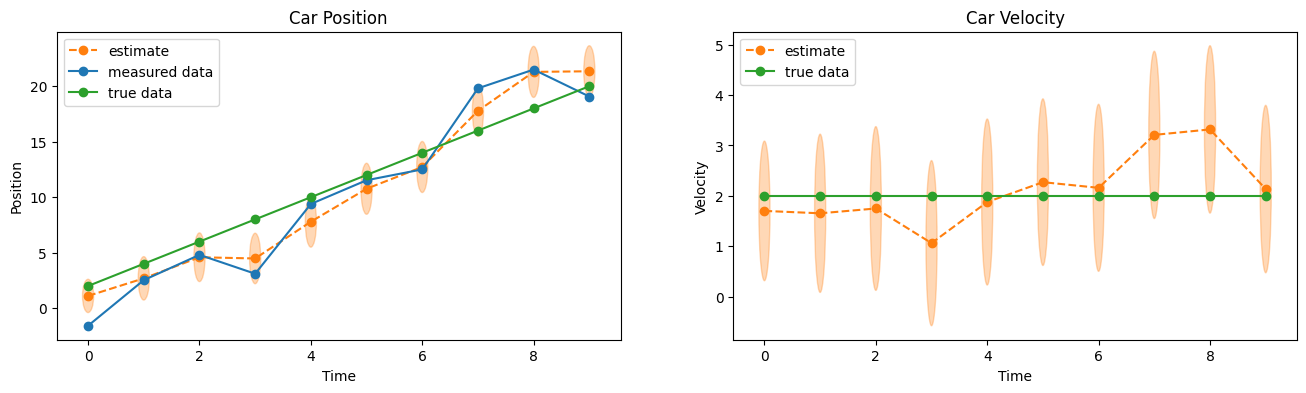

In [7]:
fig, axes = plt.subplots(nrows = 1, ncols = 2, figsize = (16, 4))

ax = axes.flatten()

plot_experiment(
    means = means[:, 0].flatten(), 
    stds = jnp.sqrt(covs[:, 0, 0]), 
    measurements = data, 
    true_data = true_positions, 
    ax = ax[0], 
    title = "Car Position", 
    xlabel = "Time", 
    ylabel = "Position"
)

plot_experiment(
    means = means[:, 1].flatten(),
    stds = jnp.sqrt(covs[:, 1, 1]),
    measurements = None,
    true_data = jnp.ones(N) * 2,
    ax = ax[1],
    title = "Car Velocity",
    xlabel = "Time",
    ylabel = "Velocity"
)

Note that time is deterministic in both graphs, so treat the widths of the ellipses as some constants not representing any uncertainty. The heights of the ellipses represent the uncertainty of the estimations of position and velocity respectively. Despite the relatively noisy observations, the filter recovers the underlying linear position trend and keeps the inferred velocity generally close to the true value of $2 \mathrm{m/s}$, while reflecting the remaining uncertainty in both state estimates.

# Kalman Smoothing

## Filtering vs Smoothing

Suppose we have information not only up to our timestamp $t$, but we have discovered the entire horizon $T$. So, we have not only $y_{1:t}$ but $y_{1:T}$. Then we can use this information to infer the current state of the model. Filtering uses:
$$ x_t \mid y_{1:t} \sim \mathcal{N}(m_t, P_t) $$
while smoothing uses:
$$ x_t \mid y_{1:T} \sim \mathcal{N}(m_t^s, P_t^s) $$

While trying to learn the dynamics online we do not have access to the future observations, thus we cant use smoothing. However, in some cases we can observe the entire trajectory, so future information might be useful for inferring the current state. Let us say that in our constant-velocity car example we have information up to some timestamp $t$. We infer that $v_t = 1.4$, however by observing more data we saw that $v_s \to 2$ as $s \to T$. This information might be quite useful for timestamp $t$ as well.

## Rauch-Tung-Striebel Smoother


Since our model is Markovian with
$$ x_t \to x_{t+1} \to x_{t+2} \to \dots $$
we can also gain information about $x_t$ through $x_{t+1}$. The following algorithm is called Rauch-Tung-Striebel (RTS) Smoother:

1. run Kalman filter forward and obtain $m_t$ and $P_t$
2. start from final timestamp $T$
3. use the information about $x_{T}$ to improve information about $x_{T-1}$
4. repeat backward $T \to T-1 \to T-2 \to \dots$

So, basically, RTS Smoother is a backward pass of the forward Kalman Filter.

### Joint Gaussian

We already assume that the state dynamics are
$$ x_{t+1} = A x_t + q_t $$
and after filtering we have
$$ x_t \mid y_{1:t} \sim \mathcal{N}(m_t, P_t) $$

Now let us inspect how $x_t$ and $x_{t+1}$ are related. From the dynamics:
$$ x_{t+1} = A x_t + q_t \Rightarrow x_{t+1} \mid y_{1:t} = A (x_t \mid y_{1:t}) + q_t $$
we already know that
$$ x_t \mid y_{1:t-1} \sim \mathcal{N}(m_t^-, P_t^-) = \mathcal{N}(A m_{t-1}, A P_{t-1} A^T + Q) $$
similarly for $x_{t+1}$:
$$ x_{t+1} \mid y_{1:t} \sim \mathcal{N}(A m_t, A P_t A^T + Q) = \mathcal{N}(m_{t+1}^-, P_{t+1}^-) $$

Now let us calculate the cross-covariance $\text{Cov}(x_{t}, x_{t+1} \mid y_{1:t})$. Since $x_{t+1} = A x_t + q_t$:
$$ \text{Cov}(x_{t}, x_{t+1} \mid y_{1:t}) = \text{Cov}(x_t, Ax_t + q_t) = \text{Cov}(x_t, Ax_t) = P_t A^T $$

So, the joint Gaussian is
$$ \begin{bmatrix} x_t \\ x_{t+1} \end{bmatrix} \mid y_{1:t} \sim \mathcal{N} \left( \begin{bmatrix} m_t \\ m_{t+1}^- \end{bmatrix}, \begin{bmatrix} P_t & P_t A^T \\ A P_t & P_{t+1}^- \end{bmatrix} \right) $$

### Conditioning

From the generic 
$$ \mathbb{E} [X \mid Y] = \mu_x + \Sigma_{XY} \Sigma_{YY}^{-1} \left( Y - \mu_Y \right) $$
$$ \text{Cov} (X \mid Y) = \Sigma_{XX} - \Sigma_{XY} \Sigma_{YY}^{-1} \Sigma_{YX} $$
defining $X = x_t, Y = x_{t+1}$:
$$ \mathbb{E} [x_t \mid x_{t+1}, y_{1:t}] = m_t + \underbrace{P_t A^T (P_{t+1}^-)^{-1}}_{=: G_t} (x_{t+1} - m_{t+1}^-) $$
$$ \text{Cov} (x_t \mid x_{t+1}, y_{1:t}) = P_t - P_tA^T (P_{t+1}^-)^{-1} AP_t = P_t - G_t P_{t+1}^- G_t^T $$

$G_t$ is called **smoothing gain** and is similar to the Kalman gain we have defined before.

Recall Kalman gain:
$$ K_t = P_t^- H^T S_t^{-1} $$

The difference is that 
* Kalman gain tells us how information about the observation $y_t$ affects the current state $x_t$
* Smoothing gain tells us how information about the next state $x_{t+1}$ affects the current state $x_t$

### Mean

For some fixed $x_{t+1}$, we know
$$ \mathbb{E} \left[ x_t \mid x_{t+1}, y_{1:t} \right] = m_t + G_t (x_{t+1} - m_{t+1}^-) $$

We want to find
$$ m_t^s = \mathbb{E} \left[ x_t \mid y_{1:T} \right] $$
Using Law of Total Expectation:
$$
\begin{aligned}
m_t^s &= \mathbb{E} \left[ x_t \mid y_{1:T} \right] \\
&= \mathbb{E} \left[ \mathbb{E} \left[ x_t \mid x_{t+1}, y_{1:T} \right] \mid y_{1:T} \right] \\
&= \mathbb{E} \left[ m_t + G_t (x_{t+1} - m_{t+1}^-) \mid y_{1:T} \right] \\
&= m_t + G_t \left( \underbrace{\mathbb{E} \left[ x_{t+1} \mid y_{1:T} \right]}_{m_{t+1}^s} - m_{t+1}^- \right) \\
&= m_t + G_t (m_{t+1}^s - m_{t+1}^-)
\end{aligned}
$$

### Covariance

In the similar fashion, we obtained, for some fixed $x_{t+1}$,
$$ \text{Cov}(x_t \mid x_{t+1}, y_{1:t}) = P_t - G_t P_{t+1}^- G_t^T $$

We want to find
$$ \text{Cov}(x_t \mid y_{1:T}) $$
Again, using Law of Total Covariance:
$$
\text{Cov}(x_t \mid y_{1:T}) = \mathbb{E} \left[ \text{Cov}(x_t \mid x_{t+1}, y_{1:T}) \mid y_{1:T} \right] + \text{Cov} \left( \mathbb{E} \left[ x_t \mid x_{t+1}, y_{1:T} \right] \mid y_{1:T} \right)
$$

The first term is:
$$ \mathbb{E} \left[ \text{Cov}(x_t \mid x_{t+1}, y_{1:T}) \right] = \mathbb{E} \left[ P_t - G_t P_{t+1}^- G_t^T \right] = P_t - G_t P_{t+1}^- G_t^T $$
since these matrices are fixed when conditioning on $y_{1:T}$

The second term is:
$$ 
\begin{aligned}
\text{Cov} \left( \mathbb{E} \left[ x_t \mid x_{t+1}, y_{1:T} \right] \right) &= \text{Cov} \left(  m_t + G_t ((x_{t+1} \mid y_{1:T}) - m_{t+1}^-) \right) \\
&= G_t \text{Cov} (x_{t+1} \mid y_{1:T}) G_t^T \\
&= G_t P_{t+1}^s G_t^T
\end{aligned}
$$

Plugging in we get
$$ 
\begin{aligned}
\text{Cov} (x_t \mid y_{1:T}) &= P_t - G_t P_{t+1}^- G_t^T + G_t P_{t+1}^s G_t^T \\
&= P_t + G_t (P_{t+1}^s - P_{t+1}^-) G_t^T
\end{aligned}
$$

Since smoothing uses more information compared to the prediction, it is generally less uncertain, thus, $P_{t+1}^s - P_{t+1}^-$ is negative semi-definite matrix. Thus, $G_t (P_{t+1}^s - P_{t+1}^-) G_t^T$ is also a negative semi-definite matrix and uncertainty after smoothing will be less than the uncertainty of filtering.

### Backward Recursion

Since at $t=T$ there is no future information,
$$ m_T = m_T^s, \quad P_T = P_T^s $$
then, at $t=T-1$ we use this to obtain smoothed $m_t^s$ and $P_t^s$. 

So the algorithm is as follows:
1. Run a forward filter and store $(m_t, P_t)$ for $t = 1, 2, \dots, T$
2. Run backward recursion using
<center>

| Formula | Description |
| :---:     |  ---:     |
| $m_{t+1}^- = A m_t$ | Prediction Mean |
| $P_{t+1}^- = A P_t A^T + Q$ | Prediction Covariance |
| $G_t = P_t A^T (P_{t+1}^-)^{-1}$ | Smoothing Gain |
| $m_t^s = m_t + G_t(m_{t+1}^s - m_{t+1}^-) $ | Smoothed Mean |
| $P_t^s = P_t + G_t (P_{t+1}^s - P_{t+1}^-) G_t^T $ | Smoothed Covariance |

</center>

## Implementation

Let us construct a new function with the similar prediction and filtering, but also with an addition of smoothing.

In [8]:
def make_kalman_filter_with_smoothing(A, Q, H, R):
    def predict(m, P):
        m_ = A @ m
        P_ = A @ P @ A.T + Q
        return m_, P_

    def condition(m_, P_, y):
        innovation = y - H @ m_
        S = H @ P_ @ H.T + R

        K = jnp.linalg.solve(S, H @ P_).T

        m = m_ + K @ innovation
        P = P_ - K @ S @ K.T

        return m, P

    def smooth(ms, Ps, m, P):
        m_, P_ = predict(m, P)
        G = jnp.linalg.solve(P_, A @ P).T

        ms = m + G @ (ms - m_)
        Ps = P + G @ (Ps - P_) @ G.T

        return ms, Ps

    return predict, condition, smooth

## Filtering vs Smoothing

Now let us run the same experiment with constant-velocity car and compare the filtered values with the smoothed ones.

In [9]:
dt = 1.0
sigma_Q = 1
sigma_R = 3
N = 10
KEY, rand_key = random.split(KEY, 2)

A = jnp.array([[1, dt], [0, 1]])
H = jnp.array([[1, 0]])
Q = jnp.eye(2) * sigma_Q**2
R = jnp.eye(1) * sigma_R**2

m0 = jnp.array([[0.], [2.]]) #velocity = 2 m/s
P0 = jnp.eye(2)

true_positions = jnp.arange(1, N+1) * 2
data = true_positions + random.normal(rand_key, (N, )) * sigma_R # measured values of the position

predict, condition, smooth = make_kalman_filter_with_smoothing(A, Q, H, R)

def forward(carry, y_t):
    m, P = carry

    m_, P_ = predict(m, P)
    m_new, P_new = condition(m_, P_, y_t)

    return ((m_new, P_new),     # new carry
            (m_new, P_new))     # saved output

def backward(carry, inputs):
    ms, Ps = carry
    m, P = inputs

    ms_new, Ps_new = smooth(ms, Ps, m, P)
    return ((ms_new, Ps_new),
            (ms_new, Ps_new))

(m_final, P_final), (means, covs) = jax.lax.scan(forward, (m0, P0), data)

means_rev = means[::-1]
covs_rev = covs[::-1]

(ms0, Ps0), (smoothed_means_rev, smoothed_covs_rev) = jax.lax.scan(backward, (means_rev[0], covs_rev[0]), (means_rev[1:], covs_rev[1:]))

smoothed_means = smoothed_means_rev[::-1]
smoothed_covs = smoothed_covs_rev[::-1]

smoothed_means = jnp.vstack([smoothed_means, means_rev[None, 0]])   # appending ms_T
smoothed_covs = jnp.vstack([smoothed_covs, covs_rev[None, 0]])      # appending Ps_T

<Axes: title={'center': 'Car Velocity Smoothed'}, xlabel='Time', ylabel='Velocity'>

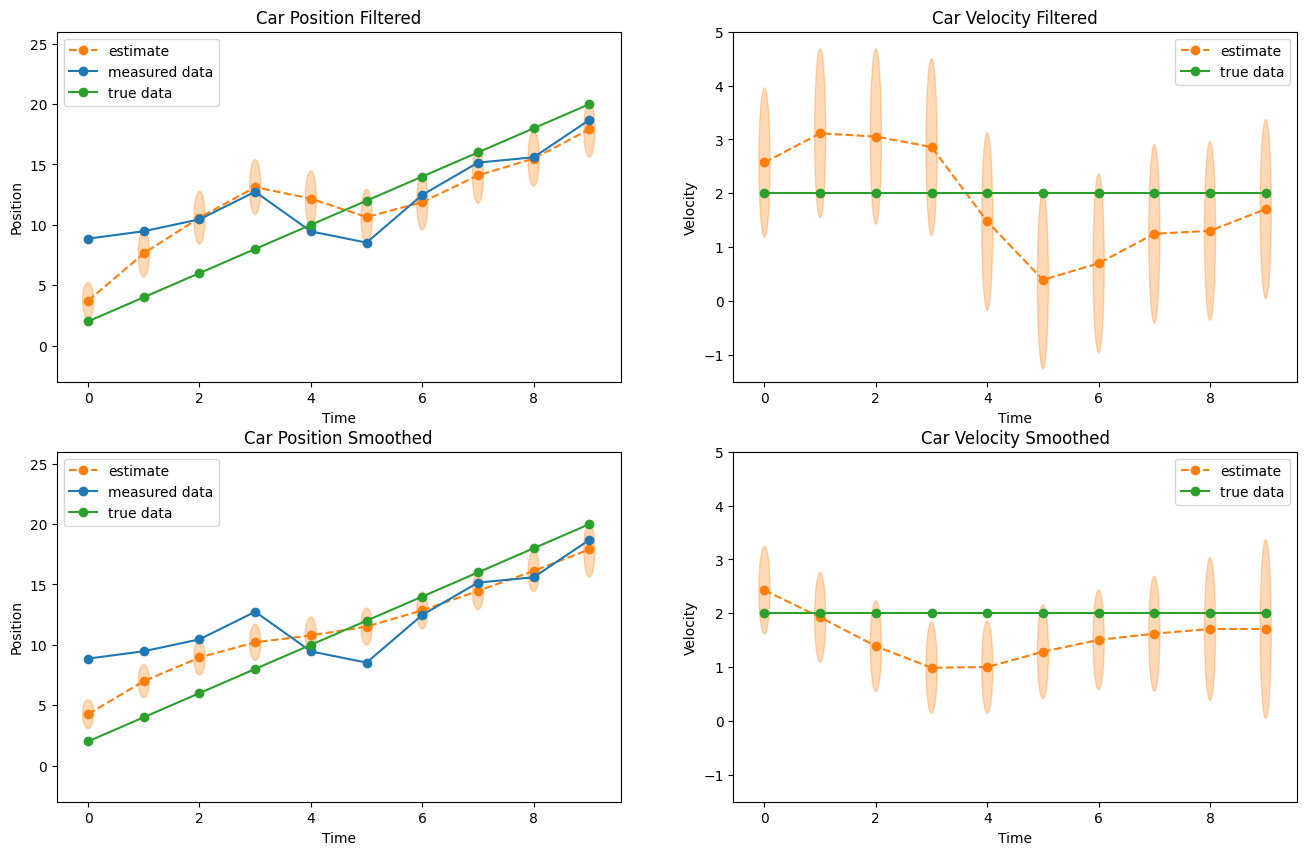

In [10]:
fig, axes = plt.subplots(nrows = 2, ncols = 2, figsize = (16, 10))

ax = axes.flatten()

plot_experiment(
    means = means[:, 0].flatten(), 
    stds = jnp.sqrt(covs[:, 0, 0]), 
    measurements = data, 
    true_data = true_positions, 
    ax = ax[0], 
    title = "Car Position Filtered", 
    xlabel = "Time", 
    ylabel = "Position", 
    ylim = (-3.0, 26.0)
)

plot_experiment(
    means = means[:, 1].flatten(),
    stds = jnp.sqrt(covs[:, 1, 1]),
    measurements = None,
    true_data = jnp.ones(N) * 2,
    ax = ax[1],
    title = "Car Velocity Filtered",
    xlabel = "Time",
    ylabel = "Velocity",
    ylim = (-1.5, 5.0)
)

plot_experiment(
    means = smoothed_means[:, 0].flatten(),
    stds = jnp.sqrt(smoothed_covs[:, 0, 0]),
    measurements = data,
    true_data = true_positions,
    ax = ax[2],
    title = "Car Position Smoothed",
    xlabel = "Time",
    ylabel = "Position",
    ylim = (-3.0, 26.0)
)

plot_experiment(
    means = smoothed_means[:, 1].flatten(),
    stds = jnp.sqrt(smoothed_covs[:, 1, 1]),
    measurements = None,
    true_data = jnp.ones(N) * 2,
    ax = ax[3],
    title = "Car Velocity Smoothed",
    xlabel = "Time",
    ylabel = "Velocity",
    ylim = (-1.5, 5.0)
)

As can be seen, the smoothed point estimates seem to be much closer to the true trajectory/state.

# Noise and Assumptions

Now let us experiment with the model. In this section three experiments will be run:
* How does the assumed process noise affect the model
* Same for observation noise
* What if the model assumption is not correct

We will consider smoothed estimations of both position and velocity of the car.

## Process Noise

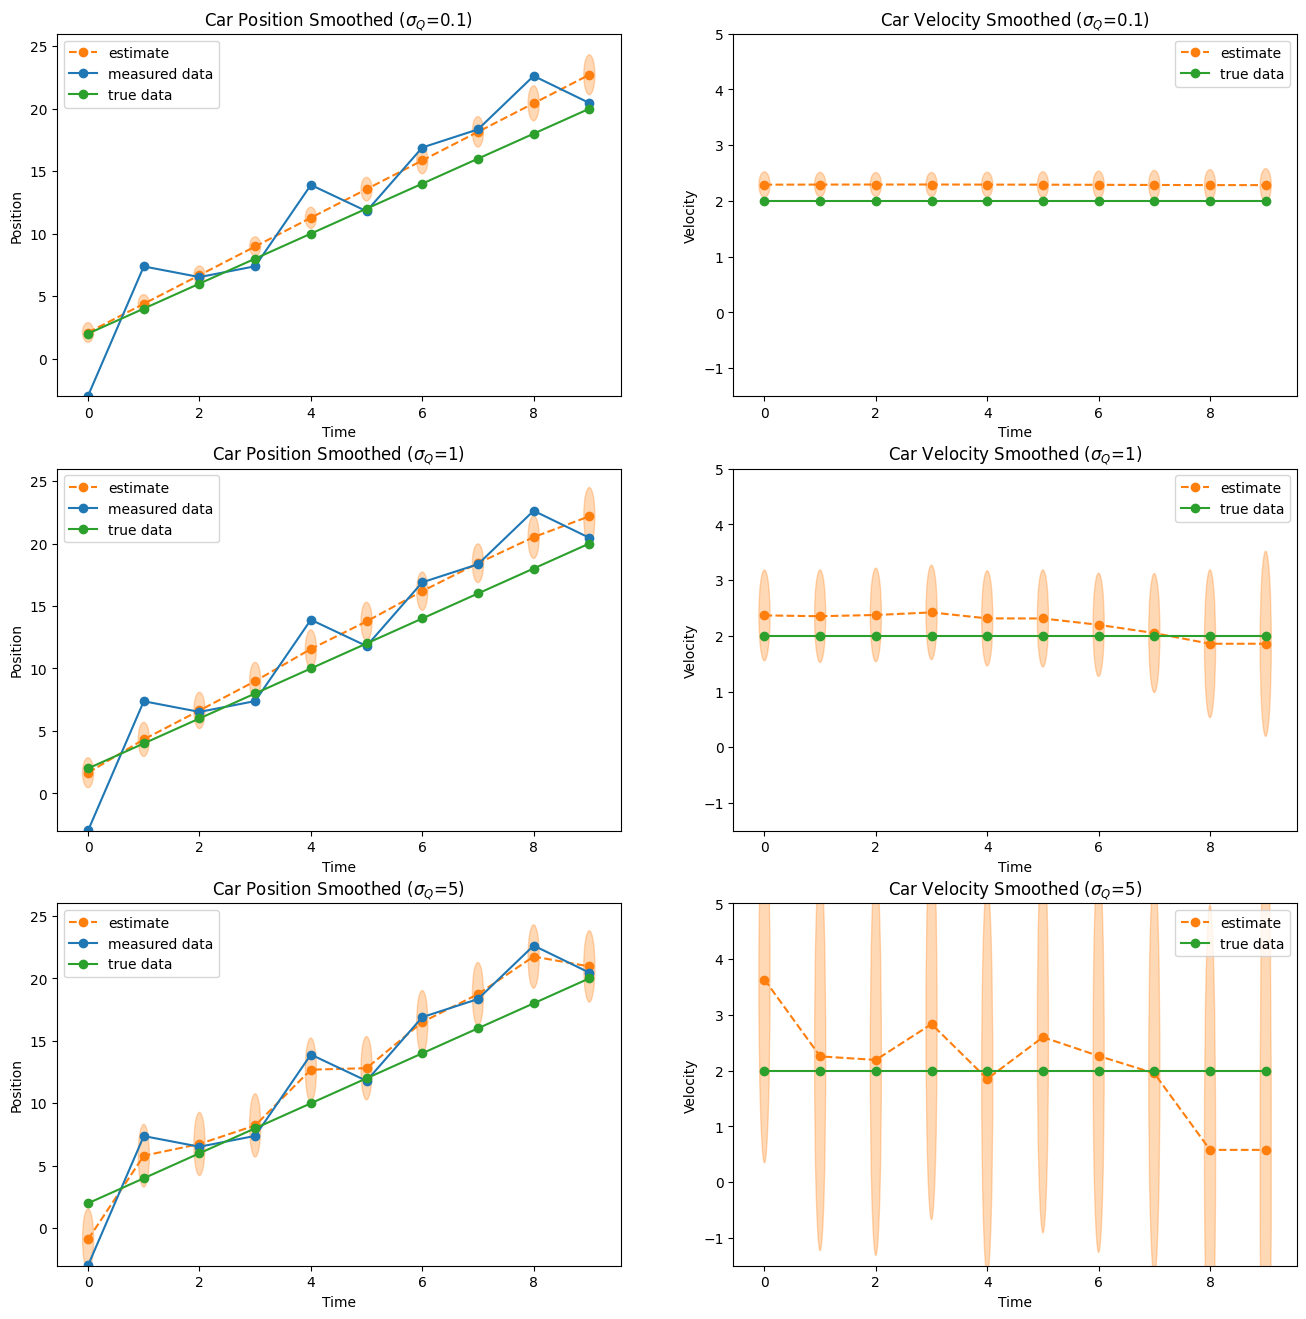

In [11]:
dt = 1.0
sigma_R = 3
N = 10
KEY, rand_key = random.split(KEY, 2)

A = jnp.array([[1, dt], [0, 1]])
H = jnp.array([[1, 0]])
R = jnp.eye(1) * sigma_R**2

m0 = jnp.array([[0.], [2.]]) #velocity = 2 m/s
P0 = jnp.eye(2)

true_positions = jnp.arange(1, N+1) * 2
data = true_positions + random.normal(rand_key, (N, )) * 3 # measured values of the position

fig, axes = plt.subplots(nrows = 3, ncols = 2, figsize = (16, 16))
ax = axes.flatten()

for i, sigma_Q in enumerate([0.1, 1, 5]):
    Q = jnp.eye(2) * sigma_Q**2
    predict, condition, smooth = make_kalman_filter_with_smoothing(A, Q, H, R)

    def forward(carry, y_t):
        m, P = carry

        m_, P_ = predict(m, P)
        m_new, P_new = condition(m_, P_, y_t)

        return ((m_new, P_new),     # new carry
                (m_new, P_new))     # saved output

    def backward(carry, inputs):
        ms, Ps = carry
        m, P = inputs

        ms_new, Ps_new = smooth(ms, Ps, m, P)
        return ((ms_new, Ps_new),
                (ms_new, Ps_new))

    (m_final, P_final), (means, covs) = jax.lax.scan(forward, (m0, P0), data)

    means_rev = means[::-1]
    covs_rev = covs[::-1]

    (ms0, Ps0), (smoothed_means_rev, smoothed_covs_rev) = jax.lax.scan(backward, (means_rev[0], covs_rev[0]), (means_rev[1:], covs_rev[1:]))

    smoothed_means = smoothed_means_rev[::-1]
    smoothed_covs = smoothed_covs_rev[::-1]

    smoothed_means = jnp.vstack([smoothed_means, means_rev[None, 0]])   # appending ms_T
    smoothed_covs = jnp.vstack([smoothed_covs, covs_rev[None, 0]])      # appending Ps_T

    plot_experiment(
        means = smoothed_means[:, 0].flatten(),
        stds = jnp.sqrt(smoothed_covs[:, 0, 0]),
        measurements = data,
        true_data = true_positions,
        ax = ax[2*i],
        title = fr"Car Position Smoothed ($\sigma_Q$={sigma_Q})",
        xlabel = "Time",
        ylabel = "Position",
        ylim = (-3.0, 26.0)
    )

    plot_experiment(
        means = smoothed_means[:, 1].flatten(),
        stds = jnp.sqrt(smoothed_covs[:, 1, 1]),
        measurements = None,
        true_data = jnp.ones(N) * 2,
        ax = ax[2*i+1],
        title = fr"Car Velocity Smoothed ($\sigma_Q$={sigma_Q})",
        xlabel = "Time",
        ylabel = "Velocity",
        ylim = (-1.5, 5.0)
    )

As $\sigma_Q$ increases, the smoother trusts the constant-velocity dynamics less and becomes increasingly responsive to noisy measurements.

* $\sigma_Q=0.1$: very smooth, highly confident, almost perfectly constant velocity.
* $\sigma_Q=1$: good balance between dynamics and observations.
* $\sigma_Q=5$: follows measurement noise much more strongly and velocity uncertainty becomes huge.

So the plot nicely illustrates that larger process noise means **less confidence in the transition model and more variable state estimates**.


## Measurement Noise

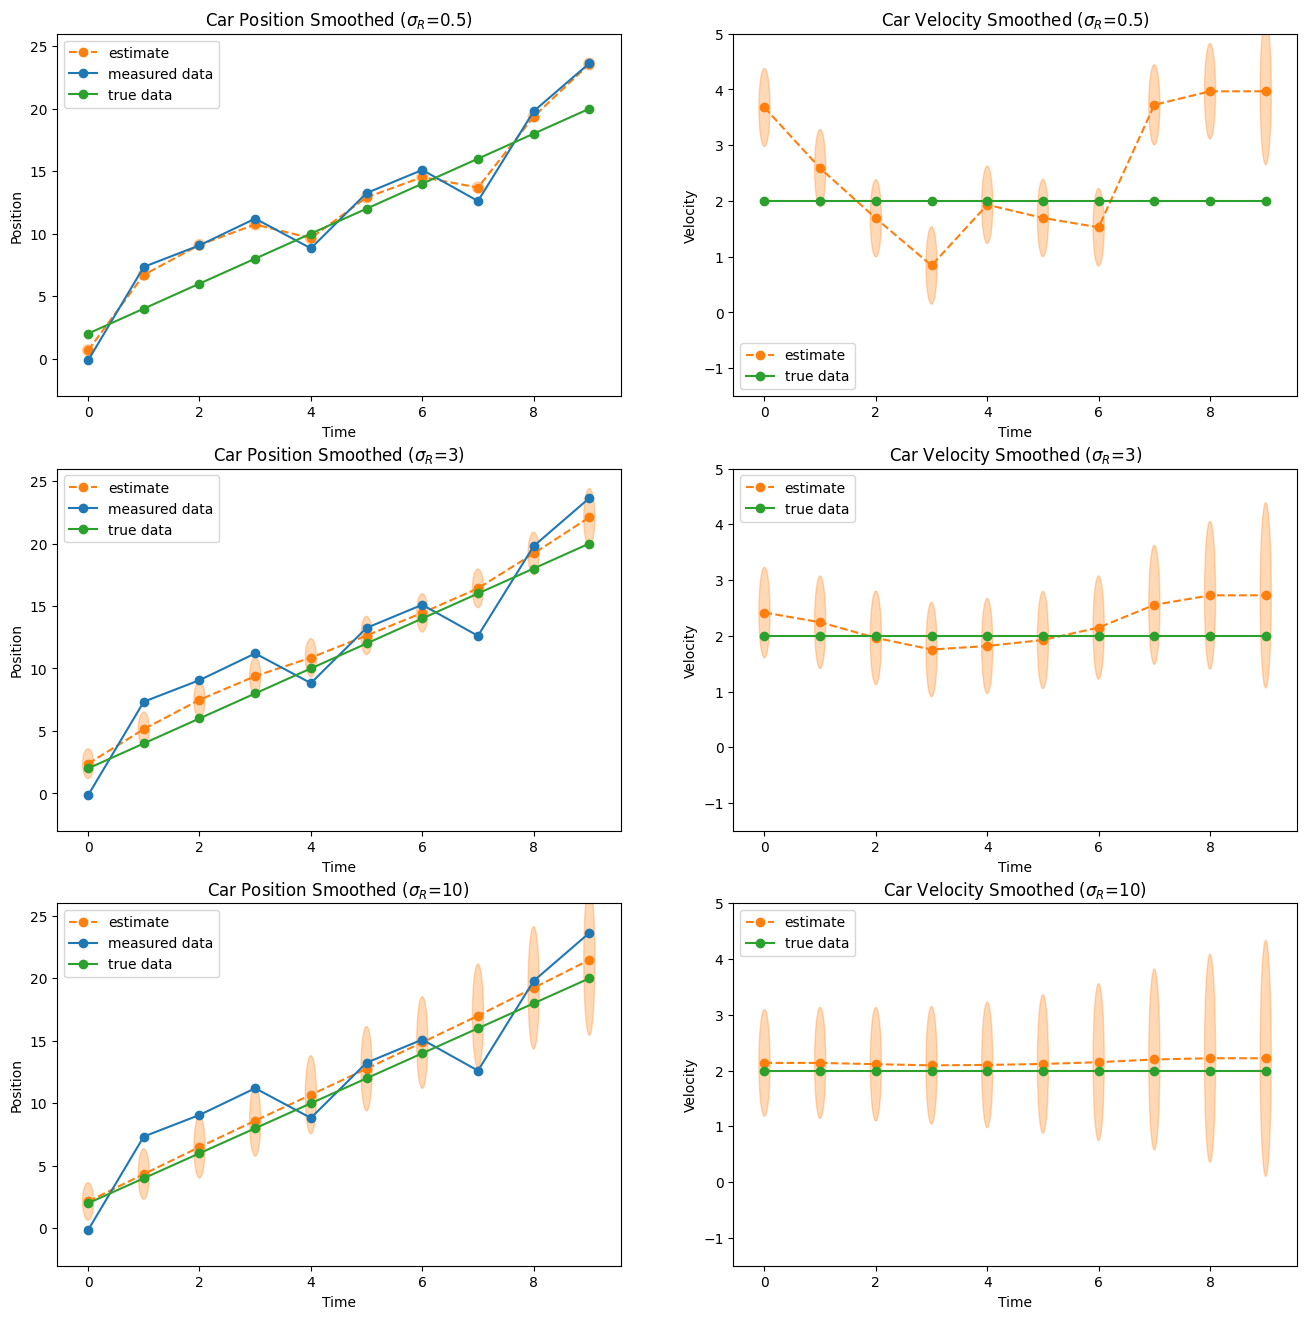

In [12]:
dt = 1.0
sigma_Q = 1
N = 10
KEY, rand_key = random.split(KEY, 2)

A = jnp.array([[1, dt], [0, 1]])
H = jnp.array([[1, 0]])
Q = jnp.eye(2) * sigma_Q**2

m0 = jnp.array([[0.], [2.]]) #velocity = 2 m/s
P0 = jnp.eye(2)

true_positions = jnp.arange(1, N+1) * 2
data = true_positions + random.normal(rand_key, (N, )) * 3 # measured values of the position

fig, axes = plt.subplots(nrows = 3, ncols = 2, figsize = (16, 16))
ax = axes.flatten()

for i, sigma_R in enumerate([0.5, 3, 10]):
    R = jnp.eye(1) * sigma_R**2
    
    predict, condition, smooth = make_kalman_filter_with_smoothing(A, Q, H, R)

    def forward(carry, y_t):
        m, P = carry

        m_, P_ = predict(m, P)
        m_new, P_new = condition(m_, P_, y_t)

        return ((m_new, P_new),     # new carry
                (m_new, P_new))     # saved output

    def backward(carry, inputs):
        ms, Ps = carry
        m, P = inputs

        ms_new, Ps_new = smooth(ms, Ps, m, P)
        return ((ms_new, Ps_new),
                (ms_new, Ps_new))

    (m_final, P_final), (means, covs) = jax.lax.scan(forward, (m0, P0), data)

    means_rev = means[::-1]
    covs_rev = covs[::-1]

    (ms0, Ps0), (smoothed_means_rev, smoothed_covs_rev) = jax.lax.scan(backward, (means_rev[0], covs_rev[0]), (means_rev[1:], covs_rev[1:]))

    smoothed_means = smoothed_means_rev[::-1]
    smoothed_covs = smoothed_covs_rev[::-1]

    smoothed_means = jnp.vstack([smoothed_means, means_rev[None, 0]])   # appending ms_T
    smoothed_covs = jnp.vstack([smoothed_covs, covs_rev[None, 0]])      # appending Ps_T

    plot_experiment(
        means = smoothed_means[:, 0].flatten(),
        stds = jnp.sqrt(smoothed_covs[:, 0, 0]),
        measurements = data,
        true_data = true_positions,
        ax = ax[2*i],
        title = fr"Car Position Smoothed ($\sigma_R$={sigma_R})",
        xlabel = "Time",
        ylabel = "Position",
        ylim = (-3.0, 26.0)
    )

    plot_experiment(
        means = smoothed_means[:, 1].flatten(),
        stds = jnp.sqrt(smoothed_covs[:, 1, 1]),
        measurements = None,
        true_data = jnp.ones(N) * 2,
        ax = ax[2*i+1],
        title = fr"Car Velocity Smoothed ($\sigma_R$={sigma_R})",
        xlabel = "Time",
        ylabel = "Velocity",
        ylim = (-1.5, 5.0)
    )

As $\sigma_R$ increases, the smoother trusts the measurements less and relies more on the constant-velocity dynamics.

* $\sigma_R=0.5$: follows noisy measurements closely, producing volatile velocity estimates.
* $\sigma_R=3$: reasonable balance.
* $\sigma_R=10$: much smoother estimates, close to the assumed dynamics, but with larger uncertainty.

So larger measurement noise means **less trust in observations and greater reliance on the transition model**.


## Modeling Assumption

Let our car move with constant acceleration, not constant velocity. In this section we will see how the model will behave under different data and change the model accordingly to our new dynamics.

Let the car start with zero velocity and accelerate with $a=1.5\ m/s^2$.

For the sake of the experiment let us use a model that is very confident in dynamics, meaning very small value of $\sigma_Q$. Since smoother sees the full data, let us examine the filter to see how it behaves in the online predictions framework.

In [13]:
dt = 1.0
a = 1.5
sigma_Q = 0.1
sigma_R = 3
N = 10
KEY, rand_key = random.split(KEY, 2)

A = jnp.array([[1, dt], [0, 1]])
H = jnp.array([[1, 0]])
Q = jnp.eye(2) * sigma_Q**2
R = jnp.eye(1) * sigma_R**2

m0 = jnp.array([[0.], [0.]]) #initial velocity = 0 m/s
P0 = jnp.eye(2)

t = jnp.arange(1, N + 1)
v0 = 0.0
true_positions = v0 * t + 0.5 * a * t**2
true_velocities = v0 + a * t

data = true_positions + random.normal(rand_key, (N, )) * sigma_R # measured values of the position

predict, condition, smooth = make_kalman_filter_with_smoothing(A, Q, H, R)

def forward(carry, y_t):
    m, P = carry

    m_, P_ = predict(m, P)
    m_new, P_new = condition(m_, P_, y_t)

    return ((m_new, P_new),     # new carry
            (m_new, P_new))     # saved output

(m_final, P_final), (means, covs) = jax.lax.scan(forward, (m0, P0), data)

<Axes: title={'center': 'Car Velocity Filtered'}, xlabel='Time', ylabel='Velocity'>

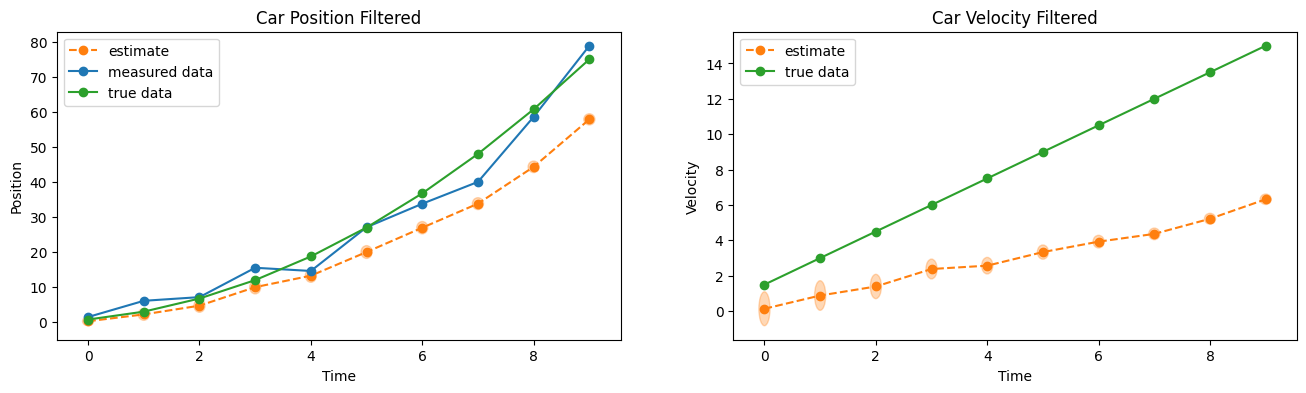

In [14]:
fig, ax = plt.subplots(nrows = 1, ncols = 2, figsize = (16, 4))

plot_experiment(
    means = means[:, 0].flatten(),
    stds = jnp.sqrt(covs[:, 0, 0]),
    measurements = data,
    true_data = true_positions,
    ax = ax[0],
    title = "Car Position Filtered",
    xlabel = "Time",
    ylabel = "Position"
)

plot_experiment(
    means = means[:, 1].flatten(),
    stds = jnp.sqrt(covs[:, 1, 1]),
    measurements = None,
    true_data = true_velocities,
    ax = ax[1],
    title = "Car Velocity Filtered",
    xlabel = "Time",
    ylabel = "Velocity"
)

As can be seen, the model is predicting both position and velocity not very well. This is due to modeling assumptions: the model expects the position changing linearly and velocity not changing at all. However, the filtered estimates still show non-linear behaviour in position and non-constant behaviour in velocity. It is due to model's observations. They are believed to be quite noisy by the construction of the experiment, but they are still affecting the model's predictions pretty much. Now let us see how we can change the model from constant-velocity to constant-acceleration.

## Constant Acceleration Model

Since now we believe that the car's position is changing quadratically and velocity is changing linearly, we should add the acceleration term to the car's state:
$$ x_t = \begin{bmatrix} p_t \\ v_t \\ a_t \end{bmatrix} $$
With model dynamics being:
$$ x_{t+1} = \begin{bmatrix} p_{t+1} \\ v_{t+1} \\ a_{t+1} \end{bmatrix} = \begin{bmatrix} p_t + v_t \Delta t + \frac{1}{2} a_t \Delta t^2 \\ v_t + a_t \Delta t \\ a_t \end{bmatrix} + \text{noise} = \begin{bmatrix} 1 & \Delta t & \frac{1}{2} \Delta t^2 \\ 0 & 1 & \Delta t \\ 0 & 0 & 1 \end{bmatrix} x_t + q_t $$

And the measurements are now made as
$$ y_t = p_t + \text{noise} = \begin{bmatrix} 1 & 0 & 0 \end{bmatrix} x_t + r_t $$

In [15]:
dt = 1.0
a = 1.5
sigma_Q = 0.1
sigma_R = 3
N = 10
KEY, rand_key = random.split(KEY, 2)

A = jnp.array([[1, dt, 0.5 * dt**2], [0, 1, dt], [0, 0, 1]])
H = jnp.array([[1, 0, 0]])
Q = jnp.eye(3) * sigma_Q**2
R = jnp.eye(1) * sigma_R**2

m0 = jnp.array([[0.], [0.], [a]])
P0 = jnp.eye(3)

t = jnp.arange(1, N + 1)
v0 = 0.0
true_positions = v0 * t + 0.5 * a * t**2
true_velocities = v0 + a * t

data = true_positions + random.normal(rand_key, (N, )) * sigma_R # measured values of the position

predict, condition, smooth = make_kalman_filter_with_smoothing(A, Q, H, R)

def forward(carry, y_t):
    m, P = carry

    m_, P_ = predict(m, P)
    m_new, P_new = condition(m_, P_, y_t)

    return ((m_new, P_new),     # new carry
            (m_new, P_new))     # saved output

(m_final, P_final), (means, covs) = jax.lax.scan(forward, (m0, P0), data)

<Axes: title={'center': 'Car Velocity Filtered'}, xlabel='Time', ylabel='Velocity'>

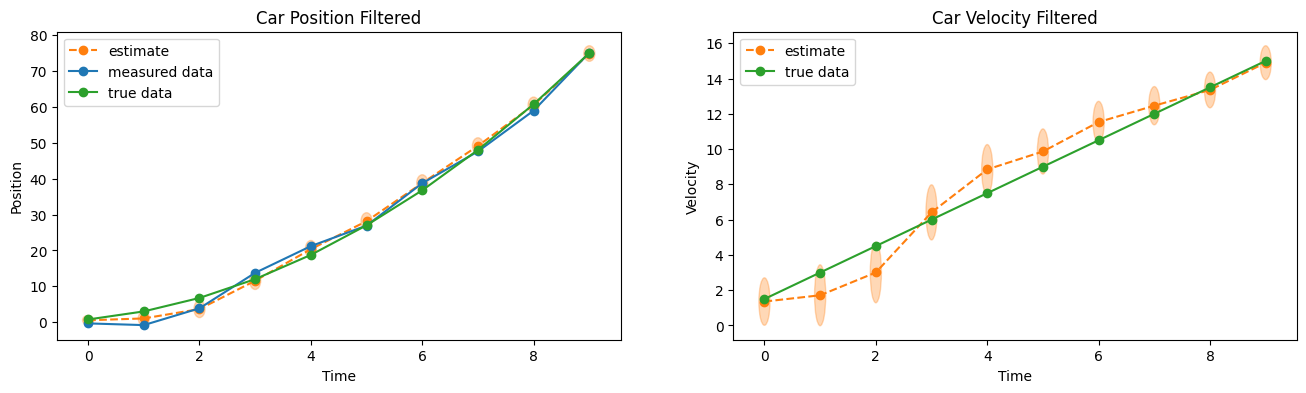

In [16]:
fig, ax = plt.subplots(nrows = 1, ncols = 2, figsize = (16, 4))

plot_experiment(
    means = means[:, 0].flatten(),
    stds = jnp.sqrt(covs[:, 0, 0]),
    measurements = data,
    true_data = true_positions,
    ax = ax[0],
    title = "Car Position Filtered",
    xlabel = "Time",
    ylabel = "Position"
)

plot_experiment(
    means = means[:, 1].flatten(),
    stds = jnp.sqrt(covs[:, 1, 1]),
    measurements = None,
    true_data = true_velocities,
    ax = ax[1],
    title = "Car Velocity Filtered",
    xlabel = "Time",
    ylabel = "Velocity"
)

Now the model behaves much better given the true dynamics and measurements.

# Continuous-Time State-Space Models

So far we have used a discrete-time model
$$ x_{t+1} = Ax_t + q_t \quad q_t \sim \mathcal{N}(0, Q) $$
assuming that model can be considered as jumps between states. However, in real life most of the dynamics evolve continuously in time. That is why let us extend the car example to continuous-time model. Let the dynamics be
$$ \frac{dx(t)}{dt} = F x(t) $$
for some linear mapping $F$. Including the noise we can write the model as
$$ dx(t) = F x(t) dt + L dB_t $$
where $B_t$ is Brownian motion:
* $B_0 = 0$
* $B_{t + \Delta t} - B_t \sim \mathcal{N}(0, Q_c \Delta t)$

So in the model above:
* $F$ is defining the general state dynamics
* $L$ is specifying what is directly affected by noise
* $Q_c$ is defining the noise level

In this section we will associate the continuous-time model to the discrete-time one considered before, namely
$$ (F, L, Q_c, \Delta t) \to (A, Q) $$

## Constant-Velocity Car Example

Let us consider our example with a car moving with constant velocity. General transition dynamics are:
$$ \begin{cases} \dot{p}(t) = v(t) \\ \dot{v}(t) = 0 \end{cases} \Rightarrow \dot{x}(t) = \begin{bmatrix} \dot{p}(t) \\ \dot{v}(t) \end{bmatrix} = \begin{bmatrix} 0 & 1 \\ 0 & 0 \end{bmatrix} x(t) $$
If we assume that the velocity might be affected by some noise we should also add it:
$$ dx(t) = F x(t) dt + L dB_t $$
with $L = \begin{bmatrix} 0 \\ 1 \end{bmatrix}$

Since $B_t$ is a Brownian motion, we can obtain
$$ \text{Cov}(B_t) = Q_c t $$
with $Q_c$ describing the noise intensity for continuous-time settings.

Also, since $B_{t + \Delta t} - B_t \sim \mathcal{N}(0, Q_c \Delta t)$, we can conclude that noise accumulates as $\Delta t$ increases.

## Discretizing the Transition Dynamics

Let us first assume that there is no noise happening, then the model is
$$ \dot{x}(t) = F x(t) $$
which is a system of linear ODEs. For a scalar equation
$$ \dot{x}(t) = a x $$
the solution is
$$ x(t) = e^{at}x(0) \Rightarrow x(t + \Delta t) = e^{a(t + \Delta t)} = e^{a \Delta t} x(t) $$
For the matrix equation
$$ \dot{x}(t) = F x(t) $$
the answer is similarly
$$ x(t + \Delta t) = e^{F \Delta t} x(t) $$
with $e^{M}$ being matrix exponential given by
$$ e^{M} = \sum_{k=0}^{\infty} \frac{1}{k!} M^k $$
The obtained result is similar to the discrete form used before
$$ x_{t+1} = Ax_t $$
with $A = e^{F \Delta t}$

Let us obtain $A$ from $F$ we have defined in the previous subsection:
$$
\begin{aligned}
A &= e^{F \Delta t} \\
&= \sum_{k=0}^{\infty} \frac{1}{k!} (F \Delta t)^k \\
&= I + F \Delta t + \underbrace{\frac{(F \Delta t)^2}{2}}_{=0} + \underbrace{\frac{(F \Delta t)^3}{6}}_{=0} + \dots \\
&= I + F \Delta t \\
&= \begin{bmatrix} 1 & \Delta t \\ 0 & 1 \end{bmatrix}
\end{aligned}
$$

So the matrix we have used for the discrete-time model was an exact discretization of the continuous-time dynamics of the constant-velocity car.

## Discretizing the Noise

Let us consider one interval of our system:
$$ dx(t) = Fx(t) dt + L dB_t $$
we want to get rid of $F x(t) dt$ term, so let us define
$$ z(t) = e^{-Ft} x(t) $$
Using Ito's product rule we obtain:
$$ 
\begin{aligned}
dz(t) &= d(e^{-Ft} x(t)) \\
&= e^{-Ft} dx(t) + x(t) d \left( e^{-Ft} \right) + \underbrace{d \left[ x(t), e^{-Ft} \right]}_{=0} \\
&= e^{-Ft} \left( Fx(t) dt + L dB_t \right) + \left( -F e^{-Ft} \right) x(t) dt \\
&= F e^{-Ft} x(t) dt + e^{-Ft} L dB_t - Fe^{-Ft} x(t) dt \\
&= e^{-Ft} L dB_t
\end{aligned}
$$

Now we can integrate both sides from $0$ to $\Delta t$:
$$ \int_{0}^{\Delta t} dz(s) = e^{-F(\Delta t)} x(\Delta t) -  x(0) = \int_{0}^{\Delta t} e^{-Fs} L dB_s $$
Now multiplying by $e^{F(\Delta t)}$:
$$ x(\Delta t) - e^{F \Delta t}x(0) = \int_{0}^{\Delta t} e^{F(\Delta t - s)} L dB_s $$

So, the final solution is
$$ x(\Delta t) = e^{F \Delta t}x(0) + \int_{0}^{\Delta t} e^{F(\Delta t - s)} L dB_s $$

Let us define the stochastic integral above as $q_0$ and consider its covariance. Since $\mathbb{E} [q_0] = 0$:
$$
\begin{aligned}
\text{Cov}(q_0) &= \mathbb{E} \left[ q_0 q_0^T \right] \\
&= \mathbb{E} \left[ \left( \int_0^{\Delta t} e^{F (\Delta t - s)} L dB_s \right) \left( \int_0^{\Delta t} e^{F (\Delta t - s)} L dB_s \right)^T \right] \\
&= \int_{0}^{\Delta t} e^{F (\Delta t - s)} L \underbrace{\mathbb{E} \left[ dB_s dB_s^T \right]}_{Q_c ds} L^T e^{F^T (\Delta t - s)} \\
&= \int_{0}^{\Delta t} e^{F (\Delta t - s)} L Q_c L^T e^{F^T (\Delta t - s)} ds \\
&= \int_{0}^{\Delta t} e^{F \tau} L Q_c L^T e^{F^T \tau} d \tau
\end{aligned}
$$

This covariance is the discrete covariance we want to use:
$$ Q_d = \int_{0}^{\Delta t} e^{F \tau} L Q_c L^T e^{F^T \tau} d \tau $$

Now let us calculate $Q_d$ for our car model. We already have:
$$ F = \begin{bmatrix} 0 & 1 \\ 0 & 0 \end{bmatrix}, \quad L = \begin{bmatrix} 0 \\ 1 \end{bmatrix} $$
Let us assume a scalar noise intensity
$$ Q_c = q $$
Then, the integral becomes
$$
\begin{aligned}
Q_d &= \int_0^{\Delta t} e^{F \tau} L Q_c L^T e^{F^T \tau} d\tau \\
&= \int_0^{\Delta t} \begin{bmatrix} 1 & \tau \\ 0 & 1 \end{bmatrix} \begin{bmatrix} 0 \\ 1 \end{bmatrix} q \begin{bmatrix} 0 & 1 \end{bmatrix} \begin{bmatrix} 1 & 0 \\ \tau & 1 \end{bmatrix} \\
&= \int_0^{\Delta t} \begin{bmatrix} \tau \\ 1 \end{bmatrix} q \begin{bmatrix} \tau & 1 \end{bmatrix} d \tau \\
&= \int_0^{\Delta t} q \begin{bmatrix} \tau^2 & \tau \\ \tau & 1 \end{bmatrix} d\tau \\
&= q \begin{bmatrix} \int_0^{\Delta t} \tau^2 d\tau & \int_0^{\Delta t} \tau d\tau \\ \int_0^{\Delta t} \tau d\tau & \int_0^{\Delta t} 1 d\tau \end{bmatrix} \\
&= q \begin{bmatrix} \frac{(\Delta t)^3}{3} & \frac{(\Delta t)^2}{2} \\ \frac{(\Delta t)^2}{2} & \Delta t \end{bmatrix}
\end{aligned}
$$

Note that in this setting we have correlated process noise $(Q_d)_{12} \neq 0$, which makes more physical sense.

Also note that increase in time between the observations now increases the uncertainty rapidly as opposed to what we had in discrete-time model.

## Implementation

To implement the general discretization function for some continuous system we can use Van Loan trick. The key identity is
$$ \exp \left( \begin{bmatrix} A & B \\ 0 & D \end{bmatrix} t \right) = \begin{bmatrix} e^{At} & \int_0^t e^{A(t-s)} B e^{Ds} ds \\ 0 & e^{Dt} \end{bmatrix} $$

Picking
$$ A = F, \quad B = L Q_c L^T, \quad D = -F^T $$
we obtain
$$ \exp \left( \begin{bmatrix} F & L Q_c L^T \\ 0 & -F^T \end{bmatrix} \Delta t \right) = \begin{bmatrix} e^{F\Delta t} & \int_0^{\Delta t} e^{F(\Delta t-s)} L Q_c L^T e^{-F^T s} ds \\ 0 & e^{-F^T \Delta t} \end{bmatrix} $$

Here we can see that we already have
$$ A = e^{F\Delta t} $$
and almost have
$$ Q_d = \int_0^{\Delta t} e^{F(\Delta t-s)} L Q_c L^T e^{F^T (\Delta t - s)} ds $$
The only thing left to obtain the discretized covariance process noise is to multiply the upper-right matrix obtained using the exponentiation by the matrix $A^T$, this will add $F^T \Delta t$ to the exponent part and finish up the calculations.

In [17]:
def discretize_continuous_system(F, L, Qc, dt):
    n = F.shape[0]

    M = jnp.block([[F, L @ Qc @ L.T], [jnp.zeros((n, n)), -F.T]])

    res = jax.scipy.linalg.expm(M * dt)

    A = res[:n, :n]
    B = res[:n, n:]

    Qd = B @ A.T
    Qd = 0.5 * (Qd + Qd.T)  #ensure symmetry

    return A, Qd

## Measurement Frequency Experiment

Let us consider how different values of $\Delta t$ affect the Kalman Filter. We will use the following values of $\Delta t$:
$$ \Delta t \in \{ 0.1, 0.5, 1, 2 \} $$
The data will be generated using $\Delta t_{\text{base}} = 0.1$ and the models will see the same measurements but with different steps:
<center>

| $\Delta t$ | Step |
| :---:     |  :---:     |
| $\Delta t = 0.1$ | Every measurement |
| $\Delta t = 0.5 $ | Every $5^{\text{th}}$ measurement |
| $\Delta t = 1 $ | Every $10^{\text{th}}$ measurement |
| $\Delta t = 2 $ | Every $20^{\text{th}}$ measurement |

</center>

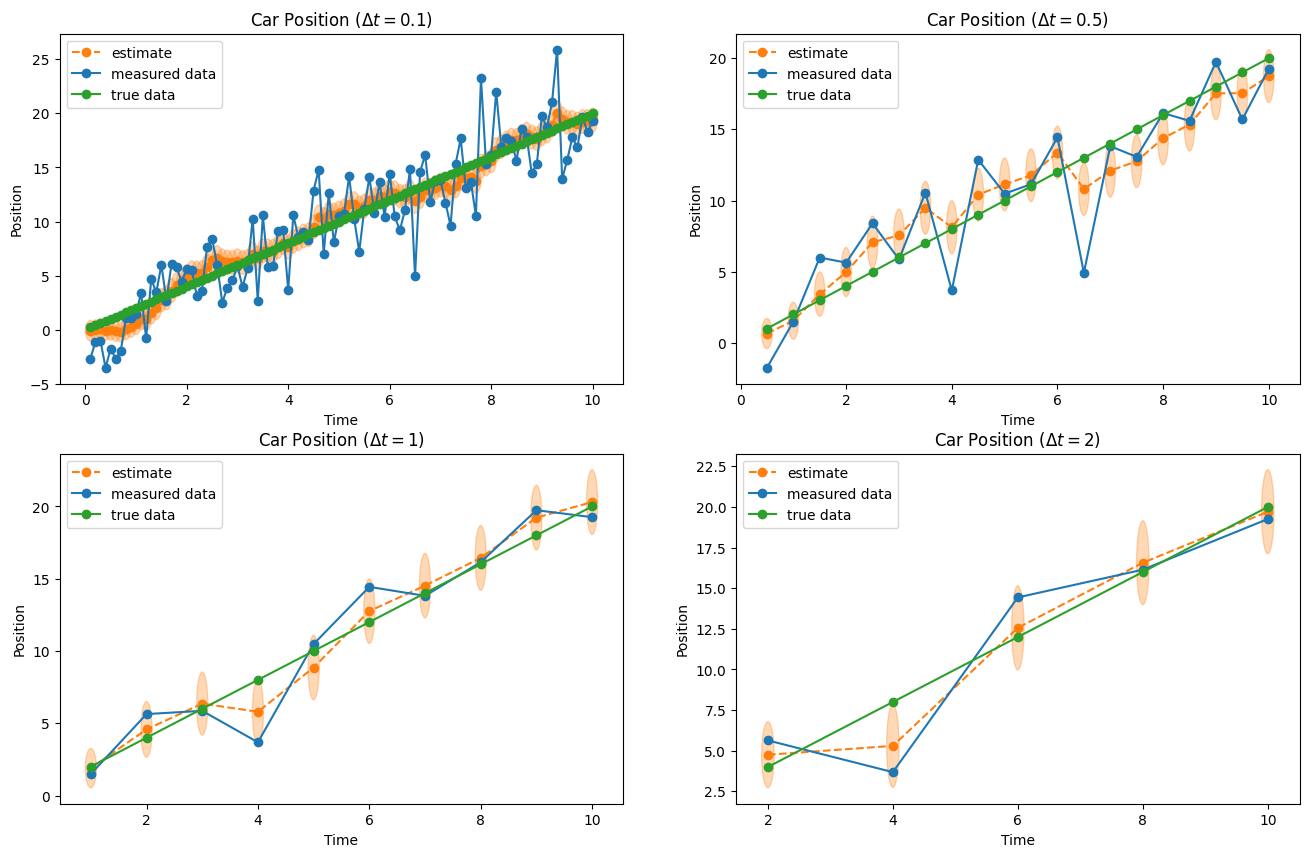

In [18]:
sigma_Q = 1
sigma_R = 3
T = 10.0
v = 2.0
q = 1.0
dt_base = 0.1
KEY, rand_key = random.split(KEY, 2)

H = jnp.array([[1, 0]])
R = jnp.eye(1) * sigma_R**2
F = jnp.array([[0, 1], [0, 0]])
L = jnp.array([[0], [1]])
Qc = jnp.array([[q]])

m0 = jnp.array([[0.], [v]]) #velocity = 2 m/s
P0 = jnp.eye(2)

fig, axes = plt.subplots(nrows = 2, ncols = 2, figsize = (16, 10))
ax = axes.flatten()

t_base = jnp.arange(dt_base, T + dt_base, dt_base)

true_positions_base = v * t_base

data_base = true_positions_base + sigma_R * random.normal(rand_key, t_base.shape)

for i, dt in enumerate([0.1, 0.5, 1, 2]):
    step = int(dt / dt_base)

    t = t_base[step - 1::step]
    true_positions = true_positions_base[step - 1::step]
    data = data_base[step - 1::step]

    A, Q = discretize_continuous_system(F, L, Qc, dt)

    predict, condition = make_kalman_filter(A, Q, H, R)

    def forward(carry, y_t):
        m, P = carry

        m_, P_ = predict(m, P)
        m_new, P_new = condition(m_, P_, y_t)

        return ((m_new, P_new),     # new carry
                (m_new, P_new))     # saved output

    (m_final, P_final), (means, covs) = jax.lax.scan(forward, (m0, P0), data)

    plot_experiment(
        means = means[:, 0].flatten(), 
        stds = jnp.sqrt(covs[:, 0, 0]), 
        measurements = data, 
        true_data = true_positions, 
        x = t,
        ax = ax[i], 
        title = fr"Car Position ($\Delta t = {dt}$)", 
        xlabel = "Time", 
        ylabel = "Position"
    )

As can be seen, as $\Delta t$ increases, more process uncertainty accumulates between observations, so each available measurement has greater relative influence; however, measurements also arrive less frequently. Since
$$ Q_d(\Delta t) = \begin{bmatrix} \frac{\Delta t^3}{3} & \frac{\Delta t^2}{2} \\ \frac{\Delta t^2}{2} & \Delta t \end{bmatrix} $$

Model is expecting more uncertainty about the position of the car with the constant uncertainty about the made measurements. Thus, it believes the measurements more.

# Extended Kalman Filter

## Nonlinear State-Space Models

Up to this point of the notebook we have considered linear state-space models
$$ x_{t+1} = Ax_t + q_t, \quad y_t = Hx_t + r_t $$
Now let us consider nonlinear models with
$$ x_{t+1} = f(x_t) + q_t, \quad y_t = h(x_t) + r_t $$
The problem here is that the Kalman Filter has used the fact that the Gaussian is closed under linear operations. However, now we have lost the linearity and the framework won't work the same way. The solution is to approximate $f$ and $h$ linearly in $x_t$ using Taylor's expansion:
$$ f(x_t) \approx f(a) + f'(a) (x_t - a) $$
for scalars and 
$$ f(x_t) \approx f(a) + F (x_t - a), \quad F = \frac{\partial f}{\partial x} \Bigm| _{x=a} $$
for vectors.

Once we have locally linearized form of the functions we can use Kalman Filter as before.

## Jacobian Linearization

### Prediction

Suppose at time $t-1$ we have
$$x_{t-1} \mid y_{1:t-1} \sim \mathcal{N}(m_{t-1}, P_{t-1})$$
and the prediction is made using
$$x_{t} = f(x_{t-1}) + q_{t-1}$$
We linearize $f$ around current mean $m_{t-1}$:
$$f(x_{t-1}) \approx f(m_{t-1}) + F_{t-1} (x_{t-1} - m_{t-1})$$
where
$$F_{t-1} = \frac{\partial f}{\partial x} \Bigm| _{x = m_{t-1}}$$
and the prediction step is now linearized as
$$x_{t} = f(m_{t-1}) + F_{t-1} (x_{t-1} - m_{t-1}) + q_{t-1}$$
The parameters of the prediction distribution can be calculated as

$$
\begin{aligned}
\mathbb{E} \left[ x_{t} \mid y_{1:t-1} \right] &= \mathbb{E} \left[ f(m_{t-1}) + F_{t-1} (x_{t-1} - m_{t-1}) + q_{t-1} \right] \\
&= \underbrace{\mathbb{E} \left[ f(m_{t-1}) \right]}_{=f(m_{t-1})} + F_{t-1} \underbrace{\mathbb{E} \left[ x_{t-1} - m_{t-1} \right]}_{=0} + \underbrace{\mathbb{E} \left[ q_{t-1} \right]}_{=0} \\ 
&= f(m_{t-1})
\end{aligned}
$$

$$
\begin{aligned}
\text{Cov}(x_{t} \mid y_{1:t-1}) &= \text{Cov} \left( \underbrace{f(m_{t-1})}_{\text{non-random}} + F_{t-1} (x_{t-1} - m_{t-1}) + \underbrace{q_{t-1}}_{\perp x_{t-1}} \right) \\
&= F_{t-1} P_{t-1} F_{t-1}^T + Q
\end{aligned}
$$

So, the predictions can be made using
$$x_{t} \mid y_{1:t-1} \approx \mathcal{N}(m_{t}^-, P_{t}^-)$$
with mean
$$ \boxed{m_{t}^- = f(m_{t-1})} $$
and covariance
$$ \boxed{P_{t}^- = F_{t-1} P_{t-1} F_{t-1}^T + Q}$$

Note that in general
$$\mathbb{E} [f(X)] \neq f(\mathbb{E} [X])$$
so the approximation might be inaccurate if the nonlinearities are very strong

### Conditioning

Here we suppose that
$$ y_t = h(x_t) + r_t $$
and we have predicted distribution
$$ x_t \mid y_{1:t-1} \approx \mathcal{N}(m_t^-, P_t^-) $$
In a similar way we approximate $h(x_t)$ using
$$ h(x_t) \approx h(m_t^-) + H_t (x_t - m_t^-) $$
where
$$ H_t = \frac{\partial h}{\partial x} \Bigm| _{x = m_{t}^-} $$
Then, the predicted observation is
$$ \hat{y}_t = h(m_t^-) $$

The innovation becomes
$$ \boxed{\nu_t = y_t - h(m_t^-)} $$
Innovation covariance becomes
$$ \boxed{S_t = H_t P_t^- H_t^T + R} $$
Kalman gain
$$ \boxed{K_t = P_t^- H_t^T S_t^{-1}} $$
Mean update
$$ \boxed{m_t = m_t^- + K_t \nu_t} $$
Covariance update
$$ \boxed{P_t = P_t^- - K_t S_t K_t^T} $$

However, let us use the Joseph form
$$ \boxed{P_t = (I - K_t H_t) P_t^- (I - K_t H_t)^T + K_t R K_t^T} $$
they are theoretically equivalent, but the Joseph form is numerically more stable.

### Implementation

In [19]:
def make_extended_kalman_filter(f, h, Q, R):
    def predict(m, P):
        F = jax.jacrev(f)(m)

        m_ = f(m)
        P_ = F @ P @ F.T + Q

        return m_, P_

    def condition(m_, P_, y_t):
        H = jax.jacrev(h)(m_)

        innovation = y_t - h(m_)
        S = H @ P_ @ H.T + R
        K = jax.scipy.linalg.solve(S, H @ P_).T

        m = m_ + K @ innovation
        I = jnp.eye(P_.shape[0])
        P = (I - K @ H) @ P_ @ (I - K @ H).T + K @ R @ K.T

        return m, P

    return predict, condition

## Example: Nonlinear Sensor

Let us now change our constant-velocity car example with nonlinear sensor. Let the dynamics still be
$$ x_{t+1} = Ax_t + q_t, \quad q_t \sim \mathcal{N}(0, Q) $$
but have nonlinear measurements
$$ y_t = p_t^2 + r_t, \quad r_t \sim \mathcal{N}(0, R) $$

So that
$$ h(x) = p^2 \Rightarrow H_t = \begin{bmatrix} 2p_t^- & 0 \end{bmatrix} $$

In [20]:
dt = 1.0
sigma_Q = 1
sigma_R = 3
N = 10
KEY, rand_key = random.split(KEY, 2)

A = jnp.array([[1, dt], [0, 1]])
Q = jnp.eye(2) * sigma_Q**2
R = jnp.eye(1) * sigma_R**2

def f(x):
    return A @ x

def h(x):
    p = x[0]
    return jnp.array([p**2])

m0 = jnp.array([0., 2.]) #velocity = 2 m/s
P0 = jnp.eye(2)

true_positions = jnp.arange(1, N+1) * 2
data = true_positions**2 + random.normal(rand_key, (N, )) * sigma_R # measured squares of the positions

predict, condition = make_extended_kalman_filter(f, h, Q, R)

def forward(carry, y_t):
    m, P = carry

    m_, P_ = predict(m, P)
    m_new, P_new = condition(m_, P_, y_t)

    return ((m_new, P_new),     # new carry
            (m_new, P_new))     # saved output

(m_final, P_final), (means, covs) = jax.lax.scan(forward, (m0, P0), data)

<Axes: title={'center': 'Car Velocity'}, xlabel='Time', ylabel='Velocity'>

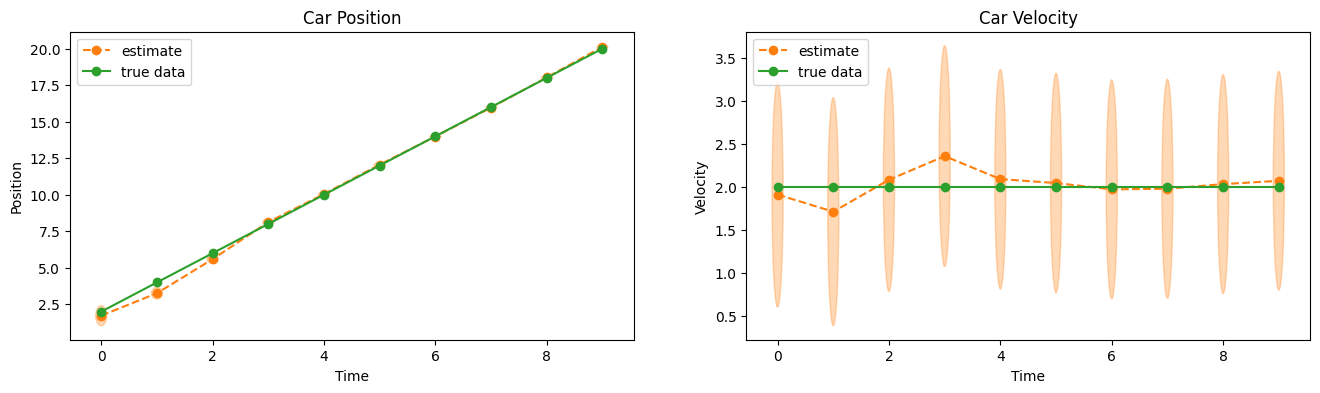

In [21]:
fig, axes = plt.subplots(nrows = 1, ncols = 2, figsize = (16, 4))

ax = axes.flatten()

plot_experiment(
    means = means[:, 0].flatten(), 
    stds = jnp.sqrt(covs[:, 0, 0]),
    true_data = true_positions, 
    ax = ax[0], 
    title = "Car Position", 
    xlabel = "Time", 
    ylabel = "Position"
)

plot_experiment(
    means = means[:, 1].flatten(),
    stds = jnp.sqrt(covs[:, 1, 1]),
    measurements = None,
    true_data = jnp.ones(N) * 2,
    ax = ax[1],
    title = "Car Velocity",
    xlabel = "Time",
    ylabel = "Velocity"
)

The EKF successfully tracks the true position from nonlinear measurements while keeping the inferred velocity close to its true constant value.

# Limitations

Although Kalman filtering provides an exact and computationally efficient solution for linear Gaussian state-space models, its performance strongly depends on the assumptions imposed on the system.

First, the standard Kalman Filter assumes linear state dynamics and a linear observation model:
$$ x_t = A x_{t-1} + q_t, \quad y_t = Hx_t + r_t $$
with Gaussian process and measurement noise. If these assumptions are strongly violated, the filtering distribution does not generally remain Gaussian and the standard Kalman Filter is no longer exact.

The quality of the estimates also depends on how well the model parameters describe the true system. In particular, incorrect transition dynamics or poorly chosen covariance matrices $Q$ and $R$ may lead to biased estimates or inappropriate uncertainty. As demonstrated in the model misspecification experiment, increasing $Q$ may allow the filter to adapt to deviations from the assumed dynamics, but it does not correct an incorrectly specified model.

The Extended Kalman Filter extends the framework to nonlinear systems by locally linearizing the transition and observation functions using their Jacobians. However, this is only a first-order approximation. For strongly nonlinear functions, large uncertainty, or poor initialization, the local linear approximation may be inaccurate and the resulting Gaussian approximation may poorly represent the true posterior.

Finally, both the standard Kalman Filter and the Extended Kalman Filter represent the state distribution using a single Gaussian. Therefore, distributions that are strongly skewed or multimodal cannot be represented accurately within this framework. In such settings, alternatives such as Unscented Kalman Filters or particle filtering may be more appropriate.

# Conclusion

In this notebook we considered sequential Bayesian inference for dynamical systems. Starting from a linear Gaussian state-space model, we derived the Kalman Filter as a repeated combination of two familiar Gaussian operations: propagation through linear dynamics and conditioning on a noisy observation.

The filtering recursion allowed us to estimate both directly observed quantities, such as the position of a moving car, and hidden components of the state, such as its velocity. We then introduced Rauch-Tung-Striebel smoothing, which uses future observations to improve estimates of past states.

The experiments with $Q$ and $R$ demonstrated how process and measurement uncertainty determine the relative trust placed in the assumed dynamics and incoming observations, while the model misspecification experiment showed that Kalman filtering is optimal only relative to the model being assumed.

We also connected discrete-time state-space models to continuous-time stochastic dynamics. In particular, the discrete transition and process-noise covariance can be obtained from the continuous system parameters through
$$ A = e^{F\Delta t} $$
and
$$ Q = \int_0^{\Delta t} e^{F\tau}LQ_cL^Te^{F^T\tau}\,d\tau $$
This demonstrated that the discrete parameters $A$ and $Q$ depend on the sampling interval and can be derived from an underlying continuous-time model rather than chosen independently.

Finally, the Extended Kalman Filter generalized the same framework to nonlinear state-space models by replacing the fixed linear mappings with local Jacobian approximations.

Thus, the main idea of the notebook can be summarized as
$$ \boxed{\text{state-space structure} + \text{Gaussian prediction} + \text{Gaussian conditioning}} $$
which provides a unified framework for filtering, smoothing, continuous-time discretization, and approximate inference in nonlinear dynamical systems.